# Synthetic Control — Texas Prison Construction & Black Male Incarceration

Reads in the state-year panel and confirms the treated unit, donor pool, and time span
ahead of building the synthetic control (Cunningham, *Causal Inference: The Mixtape*).

| | |
|---|---|
| **Treatment** | Texas prison construction program |
| **Treated unit** | `Texas` |
| **Outcome** | `bmprate` — Black male incarceration rate |
| **Panel** | 51 U.S. states + D.C., 1985\u20132000 |
| **Reference weights** | ~0.409 California + 0.108 Florida + 0.361 Illinois + 0.122 Louisiana |
| **Dataset** | pysyncon replication data |

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [24]:
df = pd.read_csv(Path("../data/raw/texas.csv"))

# set the parameters
TREATED_REGION = "Texas"
CONTROL_REGIONS = [region for region in df['state'].unique() if region not in [TREATED_REGION]]
EVENT_START = 1992



print(f"Treated unit : {TREATED_REGION}")
print(f"Donor states : {len(CONTROL_REGIONS)}")
print(f"Years        : {df['year'].min():.0f}\u2013{df['year'].max():.0f}")
print(f"Shape        : {df.shape}")
df.head()

Treated unit : Texas
Donor states : 50
Years        : 1985–2000
Shape        : (816, 24)


,statefip,year,race,bmprison,wmprison,bmpop,wmpop,error,crack,alcohol,...,perc1519,aidscapita,state,parole,probation,capacity_rated,capacity_operational,capacity_design,bmprate,wmprate
0,1.0,1985.0,2.0,6227.0,4210.0,464428,1427743,0.0,0.217438,1.90,...,8.461768,0.679504,Alabama,2425.0,16520,9787.0,9787.0,9787.0,1340.7891,294.87100
1,1.0,1986.0,1.0,6657.0,4423.0,465387,1434773,0.0,0.276875,1.90,...,8.473580,0.851692,Alabama,3038.0,21371,10374.0,10374.0,10374.0,1430.4224,308.27176
2,1.0,1987.0,1.0,7281.0,4803.0,467545,1442894,0.0,0.211371,1.89,...,8.397089,1.967214,Alabama,3456.0,23406,11107.0,11107.0,11107.0,1557.2832,332.87268
3,1.0,1988.0,1.0,7244.0,4605.0,468281,1445048,0.0,0.559781,1.89,...,8.280076,2.758137,Alabama,4701.0,25301,11162.0,11162.0,11162.0,1546.9344,318.67453
4,1.0,1989.0,1.0,8056.0,4998.0,468893,1445678,0.0,0.721824,1.87,...,8.088959,3.845907,Alabama,5724.0,25519,11162.0,11662.0,11662.0,1718.0892,345.72015


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   statefip              816 non-null    float64
 1   year                  816 non-null    float64
 2   race                  816 non-null    float64
 3   bmprison              816 non-null    float64
 4   wmprison              802 non-null    float64
 5   bmpop                 816 non-null    int64  
 6   wmpop                 816 non-null    int64  
 7   error                 816 non-null    float64
 8   crack                 816 non-null    float64
 9   alcohol               816 non-null    float64
 10  income                816 non-null    int64  
 11  ur                    816 non-null    float64
 12  poverty               816 non-null    float64
 13  black                 816 non-null    float64
 14  perc1519              816 non-null    float64
 15  aidscapita            816 non-null

In [26]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


statefip                  0
year                      0
race                      0
bmprison                  0
wmprison                 14
bmpop                     0
wmpop                     0
error                     0
crack                     0
alcohol                   0
income                    0
ur                        0
poverty                   0
black                     0
perc1519                  0
aidscapita                0
state                     0
parole                    6
probation                 0
capacity_rated          287
capacity_operational    132
capacity_design         245
bmprate                   0
wmprate                  14
dtype: int64

In [27]:
def get_synthetic_control_estimate(df, event_start, treated_region, control_regions, use_scaler=False, top_k_donors=None):
    # pivot once, over the full period — pre-period is later sliced from this
    # rather than re-filtering df, so pre- and full-period matrices share
    # identical column ordering/labels by construction
    control_pivot = df[df['state'].isin(control_regions)].pivot_table(
        index='year', columns='state', values='bmprate', aggfunc='mean'
    )
    treated_actual = df[df['state'] == treated_region].set_index('year')['bmprate']

    # weights are estimated on pre-treatment years only, so they reflect how
    # the treated region tracked donors *before* the intervention
    is_preperiod = control_pivot.index < event_start
    preperiod_control = control_pivot.loc[is_preperiod]
    # sliced from treated_actual (not a separate pivot) to guarantee the same
    # year index as preperiod_control, avoiding silent misalignment on .fit()
    preperiod_treatment = treated_actual.loc[is_preperiod]

    if top_k_donors is not None:
        # with only a handful of pre-treatment years and dozens of donor
        # states, Lasso/CV alone can't reliably tell signal from noise —
        # pre-screen to the states whose year-over-year fluctuations (not
        # raw levels, which share a national trend) track the treated unit
        # most closely, and only hand Lasso that shortlist
        control_diff = preperiod_control.diff().dropna()
        treated_diff = preperiod_treatment.diff().dropna()
        top_donors = control_diff.corrwith(treated_diff).abs().nlargest(top_k_donors).index
        control_pivot = control_pivot[top_donors]
        preperiod_control = preperiod_control[top_donors]

    preperiod_treatment = preperiod_treatment.values

    if use_scaler:
        # only X is standardized — y (gdpcap) stays in its original units, so
        # the fitted coefficients/intercept still predict on the original scale
        scaler = StandardScaler().fit(preperiod_control)
        preperiod_control_fit = scaler.transform(preperiod_control)
        control_pivot_fit = scaler.transform(control_pivot)
    else:
        preperiod_control_fit = preperiod_control
        control_pivot_fit = control_pivot

    lasso_model = LassoCV(cv=LeaveOneOut(), max_iter=10000).fit(preperiod_control_fit, preperiod_treatment)
    # index by the fitted matrix's actual columns, not a separately-built
    # region list — pivot_table sorts columns alphabetically, and a mismatched
    # list here silently mislabels which weight belongs to which region
    lasso_coefficients = pd.Series(lasso_model.coef_, index=preperiod_control.columns)

    # apply pre-period weights across the full timeline to get the
    # counterfactual trajectory for both pre- and post-treatment years
    synthetic_control = pd.Series(
        control_pivot_fit @ lasso_coefficients.values + lasso_model.intercept_,
        index=control_pivot.index,
    )
    # actual minus synthetic: negative gap = treatment lowered the outcome
    treatment_effect = treated_actual - synthetic_control

    # average post-treatment gap = estimated average treatment effect
    postperiod = treatment_effect[treatment_effect.index > event_start]
    ate = postperiod.mean()

    return ate, treatment_effect, treated_actual, synthetic_control, lasso_coefficients

In [28]:
ate, treatment_effect, treated_actual, synthetic_control, lasso_coefficients = get_synthetic_control_estimate(
    df, EVENT_START, TREATED_REGION, CONTROL_REGIONS, top_k_donors=10
)

/Users/stringer/.venvs/data/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/stringer/.venvs/data/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [29]:
lasso_coefficients.sort_values(ascending=False)

state
Maryland          0.421113
Connecticut       0.277385
Iowa              0.072869
Arizona           0.035550
South Carolina    0.000000
Illinois          0.000000
Massachusetts     0.000000
North Carolina    0.000000
West Virginia     0.000000
Florida          -0.000000
dtype: float64

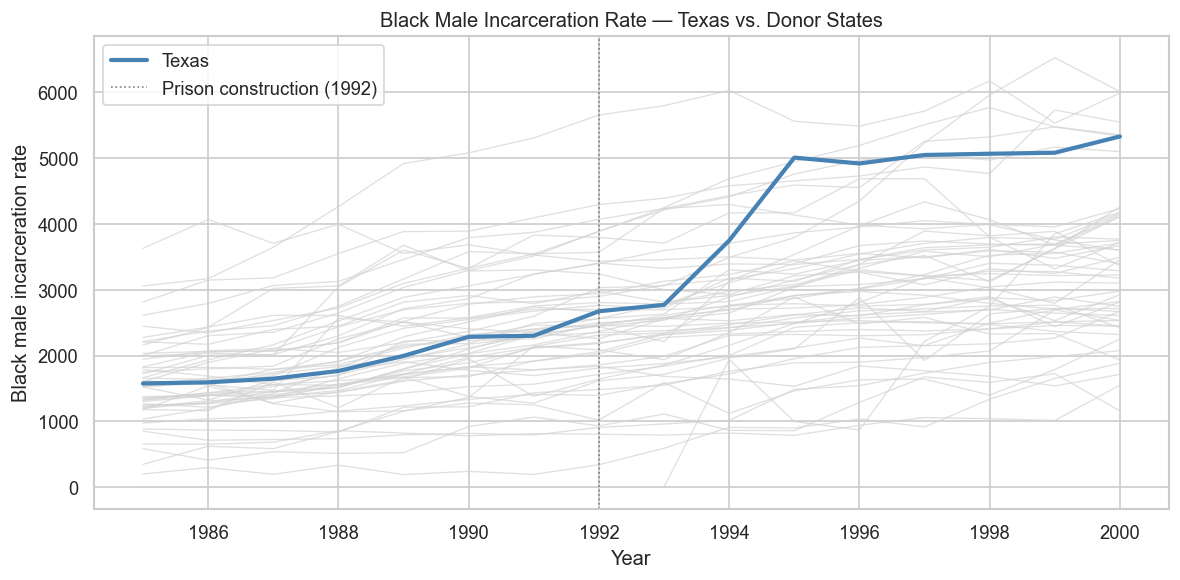

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

for state in CONTROL_REGIONS:
    s = df[df["state"] == state]
    ax.plot(s["year"], s["bmprate"], color="lightgrey", linewidth=0.8, alpha=0.7)

treated = df[df["state"] == TREATED_REGION]
ax.plot(treated["year"], treated["bmprate"], color="steelblue", linewidth=2.5, label=TREATED_REGION)
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Prison construction ({EVENT_START:.0f})")
ax.set_xlabel("Year")
ax.set_ylabel("Black male incarceration rate")
ax.set_title("Black Male Incarceration Rate — Texas vs. Donor States")
ax.legend()
plt.tight_layout()
plt.show()